## Practice Activity 7-1: Association Rules Mining

In the reading you analyzed transactions from a bakery. In this activity you will carry out a very similar analysis for purchases from a grocery store.

In [1]:
import pandas as pd

from plotnine import *

from mlxtend.frequent_patterns import apriori, association_rules

# to stop an annoying warning
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

## Groceries data set

- One month (30 days) of real point-of-sale transactions from a grocery store.
- 9,835 transactions (baskets).
- 169 product categories, such as whole milk, yogurt, bottled beer, etc.
- Source: the data set `Groceries` in the R package `arules`, provided by Hahsler, Hornik, and Reutterer. The copy we use is a plain-text version hosted on GitHub.


The file format is different from the bakery file. The bakery file had one row per item bought. This file has **one line per transaction**, and each line is a comma-separated list of the items in that basket. Different baskets have different numbers of items.

The next cell reads each line into a single text column. (Normal CSV reading expects every row to have the same number of columns, so we read each line as one string, using a separator `"|"` that never occurs in the file.)

In [2]:
import csv

raw = pd.read_csv(
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv",
    header=None,             # the file has no header row: line 1 is already a transaction
    names=["basket"],        # name the one column we create
    sep="|",                 # "|" never appears in this file, so each whole line lands in one column
    quoting=csv.QUOTE_NONE,  # treat any quote characters as ordinary text
)

In [3]:
raw

,basket
0,"citrus fruit,semi-finished bread,margarine,rea..."
1,"tropical fruit,yogurt,coffee"
2,whole milk
3,"pip fruit,yogurt,cream cheese ,meat spreads"
4,"other vegetables,whole milk,condensed milk,lon..."
...,...
9830,"sausage,chicken,beef,hamburger meat,citrus fru..."
9831,cooking chocolate
9832,"chicken,citrus fruit,other vegetables,butter,y..."
9833,"semi-finished bread,bottled water,soda,bottled..."


We'll start with the data in long format like in the reading.

- Make a column `basket_id` from the row number (`raw.index`).
- Split the text in `raw["basket"]` at the commas, using `.str.split(",")`. This produces a *list* of items in each row.
- Use `.explode(...)` on the column of lists to get one row per item.
- Keep only `basket_id` and `item`, and use `.reset_index(drop=True)`.
- Trim spaces

In [4]:
long = (
    raw
    .assign(basket_id=raw.index)                    # use the row number as the basket ID
    .assign(item=raw["basket"].str.split(","))      # "milk,bread" becomes ["milk", "bread"]
    .explode("item")                                # one row per (basket, item)
    [["basket_id", "item"]]                         # keep only the two columns we need
    .reset_index(drop=True)                         # renumber the rows 0, 1, 2, ...
)

long["item"] = long["item"].str.strip()             # remove stray leading/trailing spaces

long

,basket_id,item
0,0,citrus fruit
1,0,semi-finished bread
2,0,margarine
3,0,ready soups
4,1,tropical fruit
...,...,...
43362,9834,chicken
43363,9834,tropical fruit
43364,9834,other vegetables
43365,9834,vinegar


1. Build the transaction-by-item table `basket`. There should be one row per basket, one column per item, with `True` if the item is in the basket and `False` otherwise.

In [8]:
basket = pd.crosstab(long["basket_id"], long["item"]) > 0
print(basket.shape)
basket.iloc[:5, :6]

(9835, 169)


item,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food
basket_id,,,,,,
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False


2.  Compute the size (number of items) of each basket and store it in `basket_sizes`.

In [10]:
basket_sizes = basket.sum(axis=1)
basket_sizes.head(20)

basket_id
0     4
1     3
2     1
3     4
4     4
5     5
6     1
7     5
8     1
9     2
10    5
11    9
12    1
13    3
14    2
15    4
16    1
17    1
18    1
19    1
dtype: int64

3. Summarize the distribution of the number of items.

In [11]:
basket_sizes.describe()

count    9835.000000
mean        4.409456
std         3.589385
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        32.000000
dtype: float64

In [13]:
basket_sizes.value_counts().sort_index()           #number of baskets that contain column 1 number of items

1     2159
2     1643
3     1299
4     1005
5      855
6      645
7      545
8      438
9      350
10     246
11     182
12     117
13      78
14      77
15      55
16      46
17      29
18      14
19      14
20       9
21      11
22       4
23       6
24       1
26       1
27       1
28       1
29       3
32       1
Name: count, dtype: int64

4. Compute the support of every item, sorted from largest to smallest, and store it in `item_support`. Then make a horizontal bar chart of the 15 most popular items.

In [14]:
item_support = basket.mean().sort_values(ascending=False)
item_support.head(15)

item
whole milk          0.255516
other vegetables    0.193493
rolls/buns          0.183935
soda                0.174377
yogurt              0.139502
bottled water       0.110524
root vegetables     0.108998
tropical fruit      0.104931
shopping bags       0.098526
sausage             0.093950
pastry              0.088968
citrus fruit        0.082766
bottled beer        0.080529
newspapers          0.079817
canned beer         0.077682
dtype: float64

In [16]:
from matplotlib import font_manager, rcParams

font_manager.fontManager.addfont(
    "/System/Library/Fonts/Supplemental/Arial.ttf"
)
rcParams["font.family"] = "Arial"

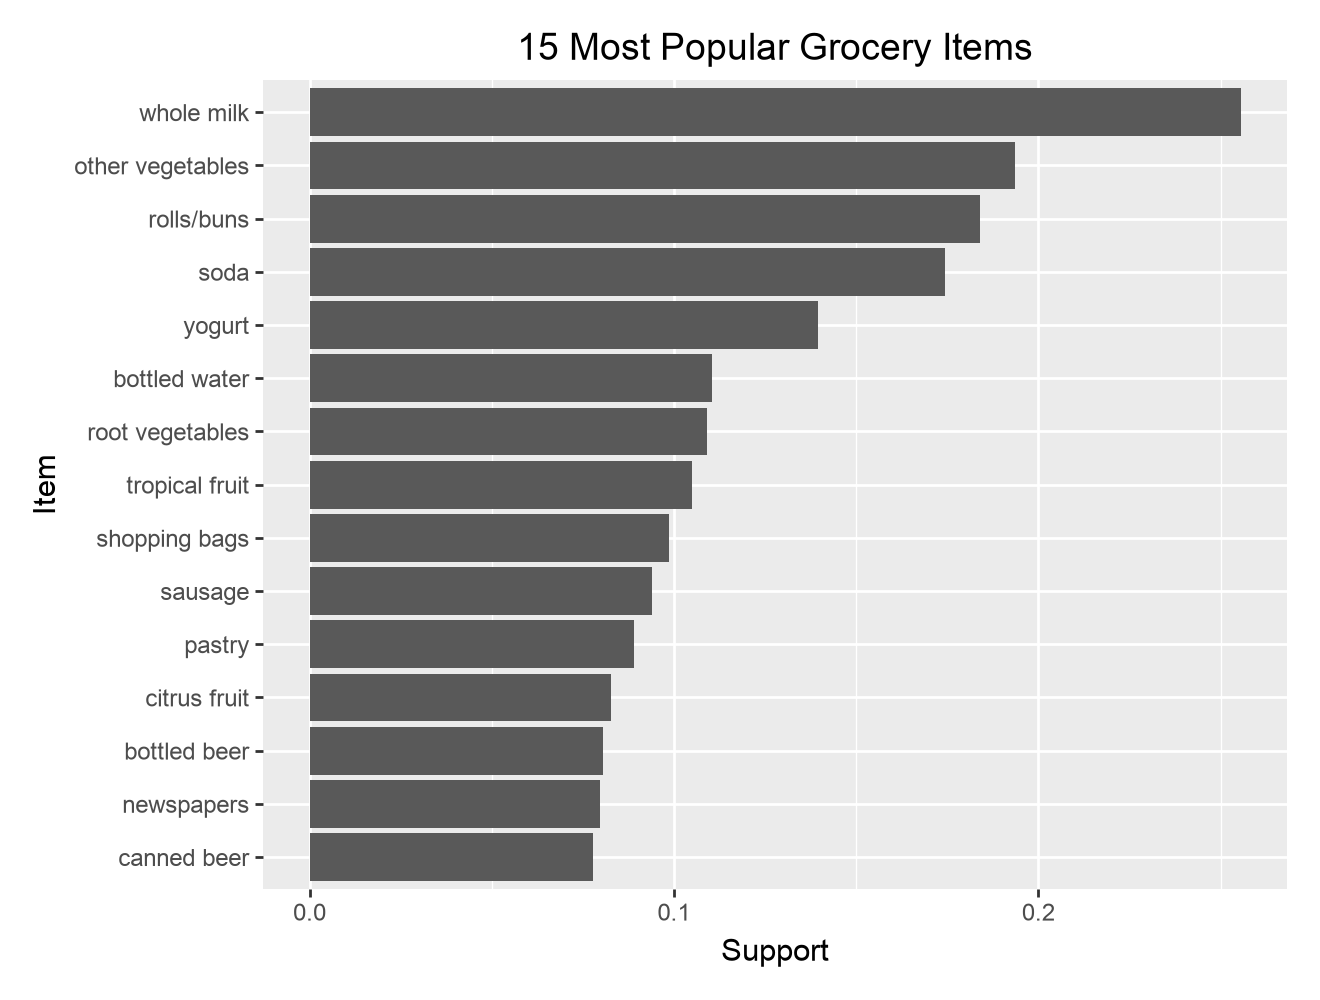

In [17]:
top_15 = (
    item_support
    .head(15)
    .rename("support")
    .reset_index()
)

(
    ggplot(top_15, aes(x="reorder(item, support)", y="support"))
    + geom_col()
    + coord_flip()
    + labs(
        x="Item",
        y="Support",
        title="15 Most Popular Grocery Items"
    )
    + theme(text=element_text(family="Arial"))
)

5. Consider the basket sizes and the item supports. Which item is most popular, and in what percentage of baskets does it appear? Which items are most common? What does this suggest about the "popular items co-occur just by chance" problem discussed in the reading?

Whole milk is the most popular item, appearing in about 25.6% of all baskets. Other vegetables, rolls/buns, soda, and yogurt are also among the most common items. Since baskets contain about 4.4 items on average and these products appear frequently on their own, popular items may occur together often simply because each is common, not necessarily because customers have a meaningful tendency to purchase them together. Therefore, co-occurrence can be misleading, and a measure like lift is more apt to compare the observed co-occurrence with what we would expect by chance.

6. Consider the rule **{yogurt} → {whole milk}**. Compute and interpret the confidence of this rule.


In [18]:
support_yogurt = basket["yogurt"].mean()

support_both = (
    basket[["yogurt", "whole milk"]]
    .all(axis=1)
    .mean()
)

confidence = support_both / support_yogurt
confidence

np.float64(0.40160349854227406)

The confidence of {yogurt} → {whole milk} is approximately 0.402. This means that about 40.2% of the baskets containing yogurt also contain whole milk.

7. Compute and interpret the **lift** of {yogurt} → {whole milk}.

In [19]:
support_whole_milk = basket["whole milk"].mean()

lift = confidence / support_whole_milk
lift

np.float64(1.5717351405345266)

The lift of {yogurt} → {whole milk} is approximately 1.57. This means that baskets containing yogurt are about 1.57 times as likely to contain whole milk as a typical basket. Because the lift is greater than 1, yogurt and whole milk have a positive association and occur together more frequently than we would expect by chance.

8. Now compute and interpret the confidence and lift for the rule {whole milk} → {yogurt}.

In [20]:
confidence_reverse = support_both / support_whole_milk

lift_reverse = support_both / (
    support_whole_milk * support_yogurt
)

print("Confidence:", confidence_reverse)
print("Lift:", lift_reverse)

Confidence: 0.21925984878631116
Lift: 1.5717351405345263


The confidence of {whole milk} → {yogurt} is approximately 0.219, meaning that about 21.9% of baskets containing whole milk also contain yogurt. The lift is approximately 1.57, so whole milk and yogurt occur together about 1.57 times as frequently as expected by chance. The confidence changes when the rule is reversed, but the lift remains the same because lift measures the association between the two items rather than the rule’s direction.

9. Write two functions.

- `support(items, onehot)`: returns the share of baskets that contain **all** of the items in the list `items`.
- `rule_metrics(antecedent, consequent, onehot)`: returns a Pandas Series with the `support`, `confidence`, and `lift` of the rule `antecedent -> consequent`. Both `antecedent` and `consequent` are *lists* of items.

Test the functions on `["yogurt"]` → `["whole milk"]`. The values should match the ones you computed earlier.

In [21]:
def support(items, onehot):
    return onehot[items].all(axis=1).mean()


def rule_metrics(antecedent, consequent, onehot):
    antecedent_support = support(antecedent, onehot)
    consequent_support = support(consequent, onehot)
    rule_support = support(antecedent + consequent, onehot)

    confidence = rule_support / antecedent_support
    lift = confidence / consequent_support

    return pd.Series({
        "support": rule_support,
        "confidence": confidence,
        "lift": lift
    })

In [22]:
rule_metrics(
    ["yogurt"],
    ["whole milk"],
    basket
)

support       0.056024
confidence    0.401603
lift          1.571735
dtype: float64

10. Whole milk is in about a quarter of all baskets. Consider the rules `{X} → {whole milk}` for the five antecedents `X` in the next cell. Before running anything, predict: for which of these will the lift be **above 1**? For which might the confidence look decent but the lift be **close to or below 1**? Just think about this before proceeding.

In [23]:
antecedents = pd.Series(["yogurt", "rolls/buns", "bottled water", "soda", "other vegetables"])

11. Compute the support, confidence, and lift of `{X} → {whole milk}` for each of the five antecedents above, and display the results sorted by lift (largest first). Compare to your predictions. Hint: Use `apply` with `lambda` on the Series of antecedents.


In [24]:
results = antecedents.apply(
    lambda x: rule_metrics([x], ["whole milk"], basket)
)

results.insert(0, "antecedent", antecedents)

results.sort_values("lift", ascending=False)

,antecedent,support,confidence,lift
0,yogurt,0.056024,0.401603,1.571735
4,other vegetables,0.074835,0.386758,1.513634
2,bottled water,0.034367,0.310948,1.216940
1,rolls/buns,0.056634,0.307905,1.205032
3,soda,0.040061,0.229738,0.899112


12. Run `apriori` on `basket` with `min_support=0.01` and store the result in `frequent_itemsets`. Then add a column `n_items` giving the number of items in each itemset.

In [25]:
frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets["n_items"] = (
    frequent_itemsets["itemsets"].apply(len)
)

frequent_itemsets

,support,itemsets,n_items
0,0.033452,(UHT-milk),1
1,0.017692,(baking powder),1
2,0.052466,(beef),1
3,0.033249,(berries),1
4,0.026029,(beverages),1
...,...,...,...
328,0.011998,"(root vegetables, whole milk, tropical fruit)",3
329,0.014540,"(root vegetables, yogurt, whole milk)",3
330,0.010473,"(soda, yogurt, whole milk)",3
331,0.015150,"(yogurt, whole milk, tropical fruit)",3


13. Generate the rules with `make_rules`, keeping rules with confidence of at least 0.20. Store them in `rules` and print how many there are.

In [26]:
def make_rules(frequent_itemsets, min_confidence):
    return association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=min_confidence
    )

In [27]:
rules = make_rules(
    frequent_itemsets,
    min_confidence=0.20
)

print(len(rules), "rules")

234 rules


14. Make the rules easier to read. Create a copy `rules_display` of `rules` and add three columns:

- `antecedent`: the antecedent items as text, e.g. `"tropical fruit, yogurt"`
- `consequent`: the consequent items as text
- `transactions`: the number of baskets that contain the whole rule (support times the number of baskets, rounded to an integer)

Then display the columns `antecedent`, `consequent`, `support`, `confidence`, `lift`, `transactions` for the first 8 rules.

In [28]:
rules_display = rules.copy()

rules_display["antecedent"] = (
    rules_display["antecedents"]
    .apply(lambda items: ", ".join(sorted(items)))
)

rules_display["consequent"] = (
    rules_display["consequents"]
    .apply(lambda items: ", ".join(sorted(items)))
)

rules_display["transactions"] = (
    rules_display["support"] * len(basket)
).round().astype(int)

In [29]:
columns_to_show = [
    "antecedent",
    "consequent",
    "support",
    "confidence",
    "lift",
    "transactions"
]

rules_display[columns_to_show].head(8)

,antecedent,consequent,support,confidence,lift,transactions
0,beef,other vegetables,0.019725,0.375969,1.943066,194
1,beef,rolls/buns,0.013625,0.259690,1.411858,134
2,beef,root vegetables,0.017387,0.331395,3.040367,171
3,beef,whole milk,0.021251,0.405039,1.585180,209
4,beef,yogurt,0.011693,0.222868,1.597601,115
5,berries,other vegetables,0.010269,0.308869,1.596280,101
6,berries,whole milk,0.011795,0.354740,1.388328,116
7,berries,yogurt,0.010574,0.318043,2.279848,104


15. Show the 10 rules with the highest **confidence**. What do the highest-confidence rules have in common? Why is confidence alone a poor guide here?

In [30]:
top_confidence = (
    rules_display
    .sort_values("confidence", ascending=False)
    [columns_to_show]
    .head(10)
)

top_confidence

,antecedent,consequent,support,confidence,lift,transactions
156,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608,102
185,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999,121
164,"curd, yogurt",whole milk,0.010066,0.582353,2.279125,99
154,"butter, other vegetables",whole milk,0.011490,0.573604,2.244885,113
222,"root vegetables, tropical fruit",whole milk,0.011998,0.570048,2.230969,118
225,"root vegetables, yogurt",whole milk,0.014540,0.562992,2.203354,143
166,"domestic eggs, other vegetables",whole milk,0.012303,0.552511,2.162336,121
233,"whipped/sour cream, yogurt",whole milk,0.010880,0.524510,2.052747,107
213,"rolls/buns, root vegetables",whole milk,0.012710,0.523013,2.046888,125
172,"other vegetables, pip fruit",whole milk,0.013523,0.517510,2.025351,133


Many of the highest-confidence rules have a very popular product, especially whole milk or other vegetables, as the consequent. Confidence alone is a poor guide because popular products appear in many baskets regardless of the antecedent. Therefore, a rule can have high confidence simply because its consequent is common, rather than because the items have a particularly strong association. Lift should also be considered because it compares the observed relationship with what would be expected by chance.

16. Show the 10 rules with the highest **lift**. Compare this list with the highest-confidence list. What kinds of products appear now? Look at the `support` and `transactions` columns: how much evidence is each of these rules based on?

In [31]:
top_lift = (
    rules_display
    .sort_values("lift", ascending=False)
    [columns_to_show]
    .head(10)
)

top_lift

,antecedent,consequent,support,confidence,lift,transactions
158,"citrus fruit, other vegetables",root vegetables,0.010371,0.359155,3.295045,102
207,"other vegetables, yogurt",whipped/sour cream,0.010168,0.234192,3.267062,100
186,"other vegetables, tropical fruit",root vegetables,0.012303,0.342776,3.144780,121
2,beef,root vegetables,0.017387,0.331395,3.040367,171
156,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608,102
185,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999,121
189,"other vegetables, whole milk",root vegetables,0.023183,0.309783,2.842082,228
190,root vegetables,"other vegetables, whole milk",0.023183,0.212687,2.842082,228
155,butter,"other vegetables, whole milk",0.011490,0.207339,2.770630,113
163,"curd, whole milk",yogurt,0.010066,0.385214,2.761356,99


The highest-lift list contains more specific combinations of related products, rather than being dominated by popular products such as whole milk. These rules represent items that occur together substantially more often than expected by chance. However, their support is generally low, and many are based on only about 1–2% of the baskets, or roughly 100–200 transactions. Thus, the high lift suggests a strong association, but the relatively small number of transactions means there is less evidence supporting each rule than there may be for more common combinations.

17. Create `interesting_rules`: the rules with **confidence of at least 0.30 and lift of at least 1.5**, sorted by lift (largest first).


In [32]:
interesting_rules = (
    rules_display
    .loc[
        (rules_display["confidence"] >= 0.30)
        & (rules_display["lift"] >= 1.5)
    ]
    .sort_values("lift", ascending=False)
    .copy()
)

interesting_rules[columns_to_show]

,antecedent,consequent,support,confidence,lift,transactions
158,"citrus fruit, other vegetables",root vegetables,0.010371,0.359155,3.295045,102
186,"other vegetables, tropical fruit",root vegetables,0.012303,0.342776,3.144780,121
2,beef,root vegetables,0.017387,0.331395,3.040367,171
156,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608,102
185,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999,121
...,...,...,...,...,...,...
89,onions,whole milk,0.012100,0.390164,1.526965,119
72,hygiene articles,whole milk,0.012811,0.388889,1.521975,126
17,brown bread,whole milk,0.025216,0.388715,1.521293,248
106,other vegetables,whole milk,0.074835,0.386758,1.513634,736


18. Choose **one** rule from the table and interpret its **support**, **confidence**, and **lift** with numbers, as you did for {yogurt} → {whole milk}.

In [33]:
chosen_rule = interesting_rules.iloc[0]

chosen_rule[columns_to_show]

antecedent      citrus fruit, other vegetables
consequent                     root vegetables
support                               0.010371
confidence                            0.359155
lift                                  3.295045
transactions                               102
Name: 158, dtype: object

In [34]:
print(
    f"The rule {{{chosen_rule['antecedent']}}} → "
    f"{{{chosen_rule['consequent']}}} has support "
    f"{chosen_rule['support']:.1%}, meaning that both sides of the rule "
    f"appear together in {chosen_rule['support']:.1%} of all baskets. "
    f"Its confidence is {chosen_rule['confidence']:.1%}, meaning that "
    f"{chosen_rule['confidence']:.1%} of baskets containing "
    f"{chosen_rule['antecedent']} also contain "
    f"{chosen_rule['consequent']}. Its lift is "
    f"{chosen_rule['lift']:.2f}, so these items occur together "
    f"{chosen_rule['lift']:.2f} times as often as expected by chance."
)

The rule {citrus fruit, other vegetables} → {root vegetables} has support 1.0%, meaning that both sides of the rule appear together in 1.0% of all baskets. Its confidence is 35.9%, meaning that 35.9% of baskets containing citrus fruit, other vegetables also contain root vegetables. Its lift is 3.30, so these items occur together 3.30 times as often as expected by chance.


19. The manager wants to **increase sales of yogurt**. Which products should the store link to yogurt (shelf placement, a joint promotion, a recommendation)?

In [35]:
yogurt_rules = (
    rules_display
    .loc[
        (rules_display["consequents"] == frozenset({"yogurt"}))
        & (rules_display["antecedents"].apply(len) == 1)
    ]
    .sort_values("lift", ascending=False)
)

yogurt_rules[columns_to_show].head(10)

,antecedent,consequent,support,confidence,lift,transactions
47,curd,yogurt,0.017285,0.324427,2.325615,170
7,berries,yogurt,0.010574,0.318043,2.279848,104
43,cream cheese,yogurt,0.012405,0.312821,2.242412,122
147,whipped/sour cream,yogurt,0.020742,0.289362,2.074251,204
144,tropical fruit,yogurt,0.029283,0.279070,2.000475,288
23,butter,yogurt,0.014642,0.264220,1.894027,144
38,citrus fruit,yogurt,0.021657,0.261671,1.875752,213
67,fruit/vegetable juice,yogurt,0.018709,0.258790,1.855105,184
62,frozen vegetables,yogurt,0.012405,0.257928,1.848924,122
78,margarine,yogurt,0.014235,0.243056,1.742312,140


The store should consider linking yogurt with products such as curd, whipped/sour cream, and tropical fruit. These products have positive lift values with yogurt, meaning that customers purchase them with yogurt more frequently than would be expected by chance. Curd appears to have one of the strongest relationships with yogurt. Whole milk could also be considered because it occurs with yogurt relatively often, although its lift is less impressive because whole milk is already a very popular product. The store should consider both lift and the number of supporting transactions before choosing a promotion.

---
## References and attribution


- Hahsler, M., Gr&uuml;n, B., and Hornik, K. (2005). arules: A computational environment for mining association rules and frequent item sets. *Journal of Statistical Software*, 14(15). (The R package that distributes the data.)
- Data copy: GitHub repository `stedy/Machine-Learning-with-R-datasets` (`groceries.csv`), the data used in Lantz, B., *Machine Learning with R*.
- Raschka, S. (2018). MLxtend: Providing machine learning and data science utilities and extensions to Python's scientific computing stack. *Journal of Open Source Software*, 3(24), 638. <https://doi.org/10.21105/joss.00638>


**Preparation of this notebook:** drafted with the assistance of generative AI tools (ChatGPT and Claude).